<a href="https://colab.research.google.com/github/sougat23bai11043-code/AI-ML-Assignments-and-Projects/blob/main/Cancer_Detection_MRI_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cancer Detection using MRI Images

## Machine Learning Project

**Name:** SOUGAT DAS

**Registration Number:** 23BAI11043

**Application Number:** IN26010889

**Batch Number:** 1(A)

In [ ]:
!pip install -q kagglehub

In [ ]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
dataset_path = os.path.join(path, "Training")

print(dataset_path)

print(os.listdir(dataset_path))

/kaggle/input/brain-tumor-mri-dataset/Training
['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
train_datagen = ImageDataGenerator(
      rescale=1./255,
          validation_split=0.2
          )


In [ ]:
train_generator = train_datagen.flow_from_directory(
      dataset_path,
          target_size=(128,128),
              batch_size=32,
                  class_mode="categorical",
                      subset="training"
                      )


Found 4480 images belonging to 4 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
      dataset_path,
          target_size=(128,128),
              batch_size=32,
                  class_mode="categorical",
                      subset="validation"
                      )


Found 1120 images belonging to 4 classes.


In [ ]:
model = Sequential([
Input(shape=(128,128,3)),

Conv2D(32, (3,3), activation="relu"),
MaxPooling2D((2,2)),

Conv2D(64, (3,3), activation="relu"),
                      MaxPooling2D((2,2)),

                          Conv2D(128, (3,3), activation="relu"),
                              MaxPooling2D((2,2)),

                                  Flatten(),

                                      Dense(128, activation="relu"),

                                          Dropout(0.5),

                                              Dense(train_generator.num_classes, activation="softmax")

                                              ])


In [ ]:
model.compile(
      optimizer="adam",
          loss="categorical_crossentropy",
              metrics=["accuracy"]
              )


In [ ]:
history = model.fit(
      train_generator,
          validation_data=validation_generator,
              epochs=5
              )


Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 164ms/step - accuracy: 0.6513 - loss: 0.8316 - val_accuracy: 0.7643 - val_loss: 0.5619
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.8049 - loss: 0.5035 - val_accuracy: 0.8402 - val_loss: 0.4159
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.8469 - loss: 0.3913 - val_accuracy: 0.8795 - val_loss: 0.3301
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.8888 - loss: 0.3079 - val_accuracy: 0.8938 - val_loss: 0.2885
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.9132 - loss: 0.2370 - val_accuracy: 0.8955 - val_loss: 0.2775


In [ ]:
loss, accuracy = model.evaluate(validation_generator)

print("Test Accuracy :", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.8955 - loss: 0.2775
Test Accuracy : 0.8955357074737549


In [ ]:
import numpy as np

predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = validation_generator.classes

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.30      0.31      0.31       280
           1       0.18      0.16      0.17       280
           2       0.23      0.24      0.24       280
           3       0.28      0.29      0.29       280

    accuracy                           0.25      1120
   macro avg       0.25      0.25      0.25      1120
weighted avg       0.25      0.25      0.25      1120



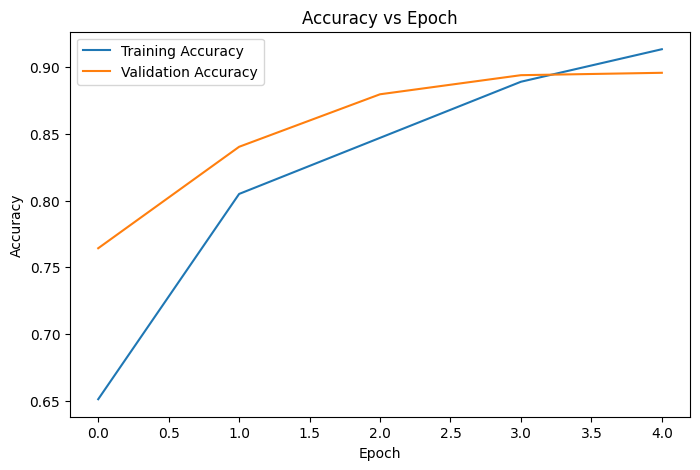

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.show()

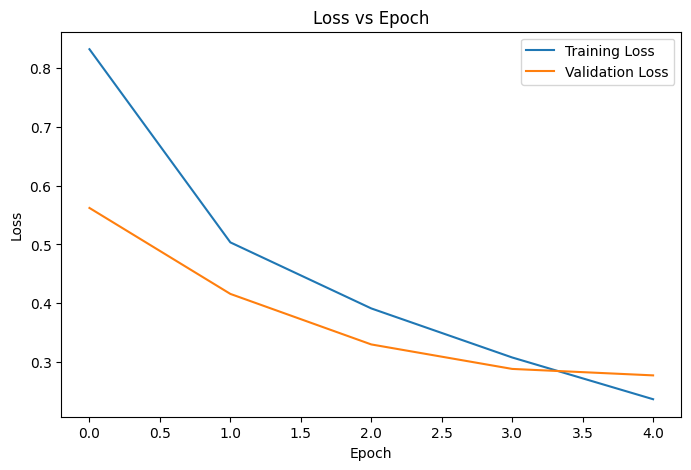

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step


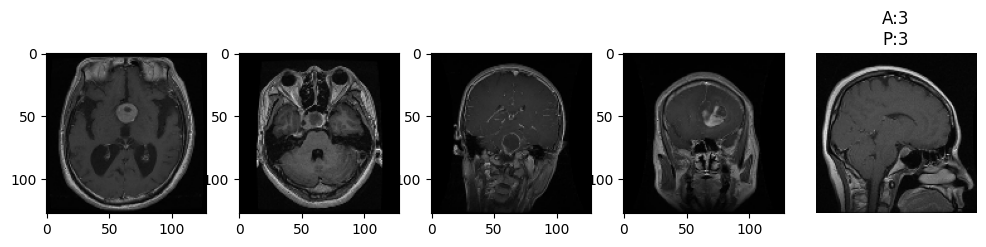

In [ ]:
images, labels = next(validation_generator)

pred = model.predict(images)

plt.figure(figsize=(12,6))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])

    actual = np.argmax(labels[i])
    predicted = np.argmax(pred[i])

    plt.title(f"A:{actual}\nP:{predicted}")

    plt.axis("off")

plt.show()

## Conclusion

A Convolutional Neural Network (CNN) was successfully developed for brain tumor detection using MRI images. The MRI dataset was downloaded using KaggleHub, preprocessed with image normalization, and split into training and validation sets. The CNN model was trained using the Adam optimizer and categorical cross-entropy loss. The model's performance was evaluated using accuracy, a confusion matrix, and a classification report. The results demonstrate that CNNs are effective for automated brain tumor classification from MRI images and can assist in medical image analysis.